<a href="https://colab.research.google.com/github/Chuty1028/Intro_DATOS_UFMa-o2/blob/main/Caso_de_Estudio_1_Intro_a_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introducción a Datos**
##### Caso de Estudio 1 (Starbucks)

Alexander López - 20250555

Daniel Piñol - 2025


**Pipeline de Datos (Starbucks)**

- Paso 1: El cliente compra en la tienda, esto incluye monto, producto, tienda y ID del cliente.

- Paso 2: Si el cliente tiene la app y utiliza el QR, el cliente esta identificado, por el contrario, el cliente no entra a rewards.

- Paso 3: Starbucks utiliza un POS propio basado en Oracle MICROS Simphony. Está conectado a la nube, app móvil, inventario y sistemas corporativos. El POS envia el evento de compra al sistema central.

- Paso 4: Se le aplican las reglas de punto por Q gastados, es un sistema 1 a 1.

- Paso 5: Se actualiza el perfil del cliente, esto quiere decir cuanto puntos lleva acumulados, historial de compras y frencuencia.

- Paso 6: Se generan las recompensas, si cumple con ciertas condiciones el cliente puede obtener por ejemplo una bebida gratis.

- Paso 7: Los datos se almacenan en dos bases, la primera es la data warehouse (donde se analizan los datos), en segundo el data lake, el cual solo es un historial.


**Data Lifecycle Manangment**

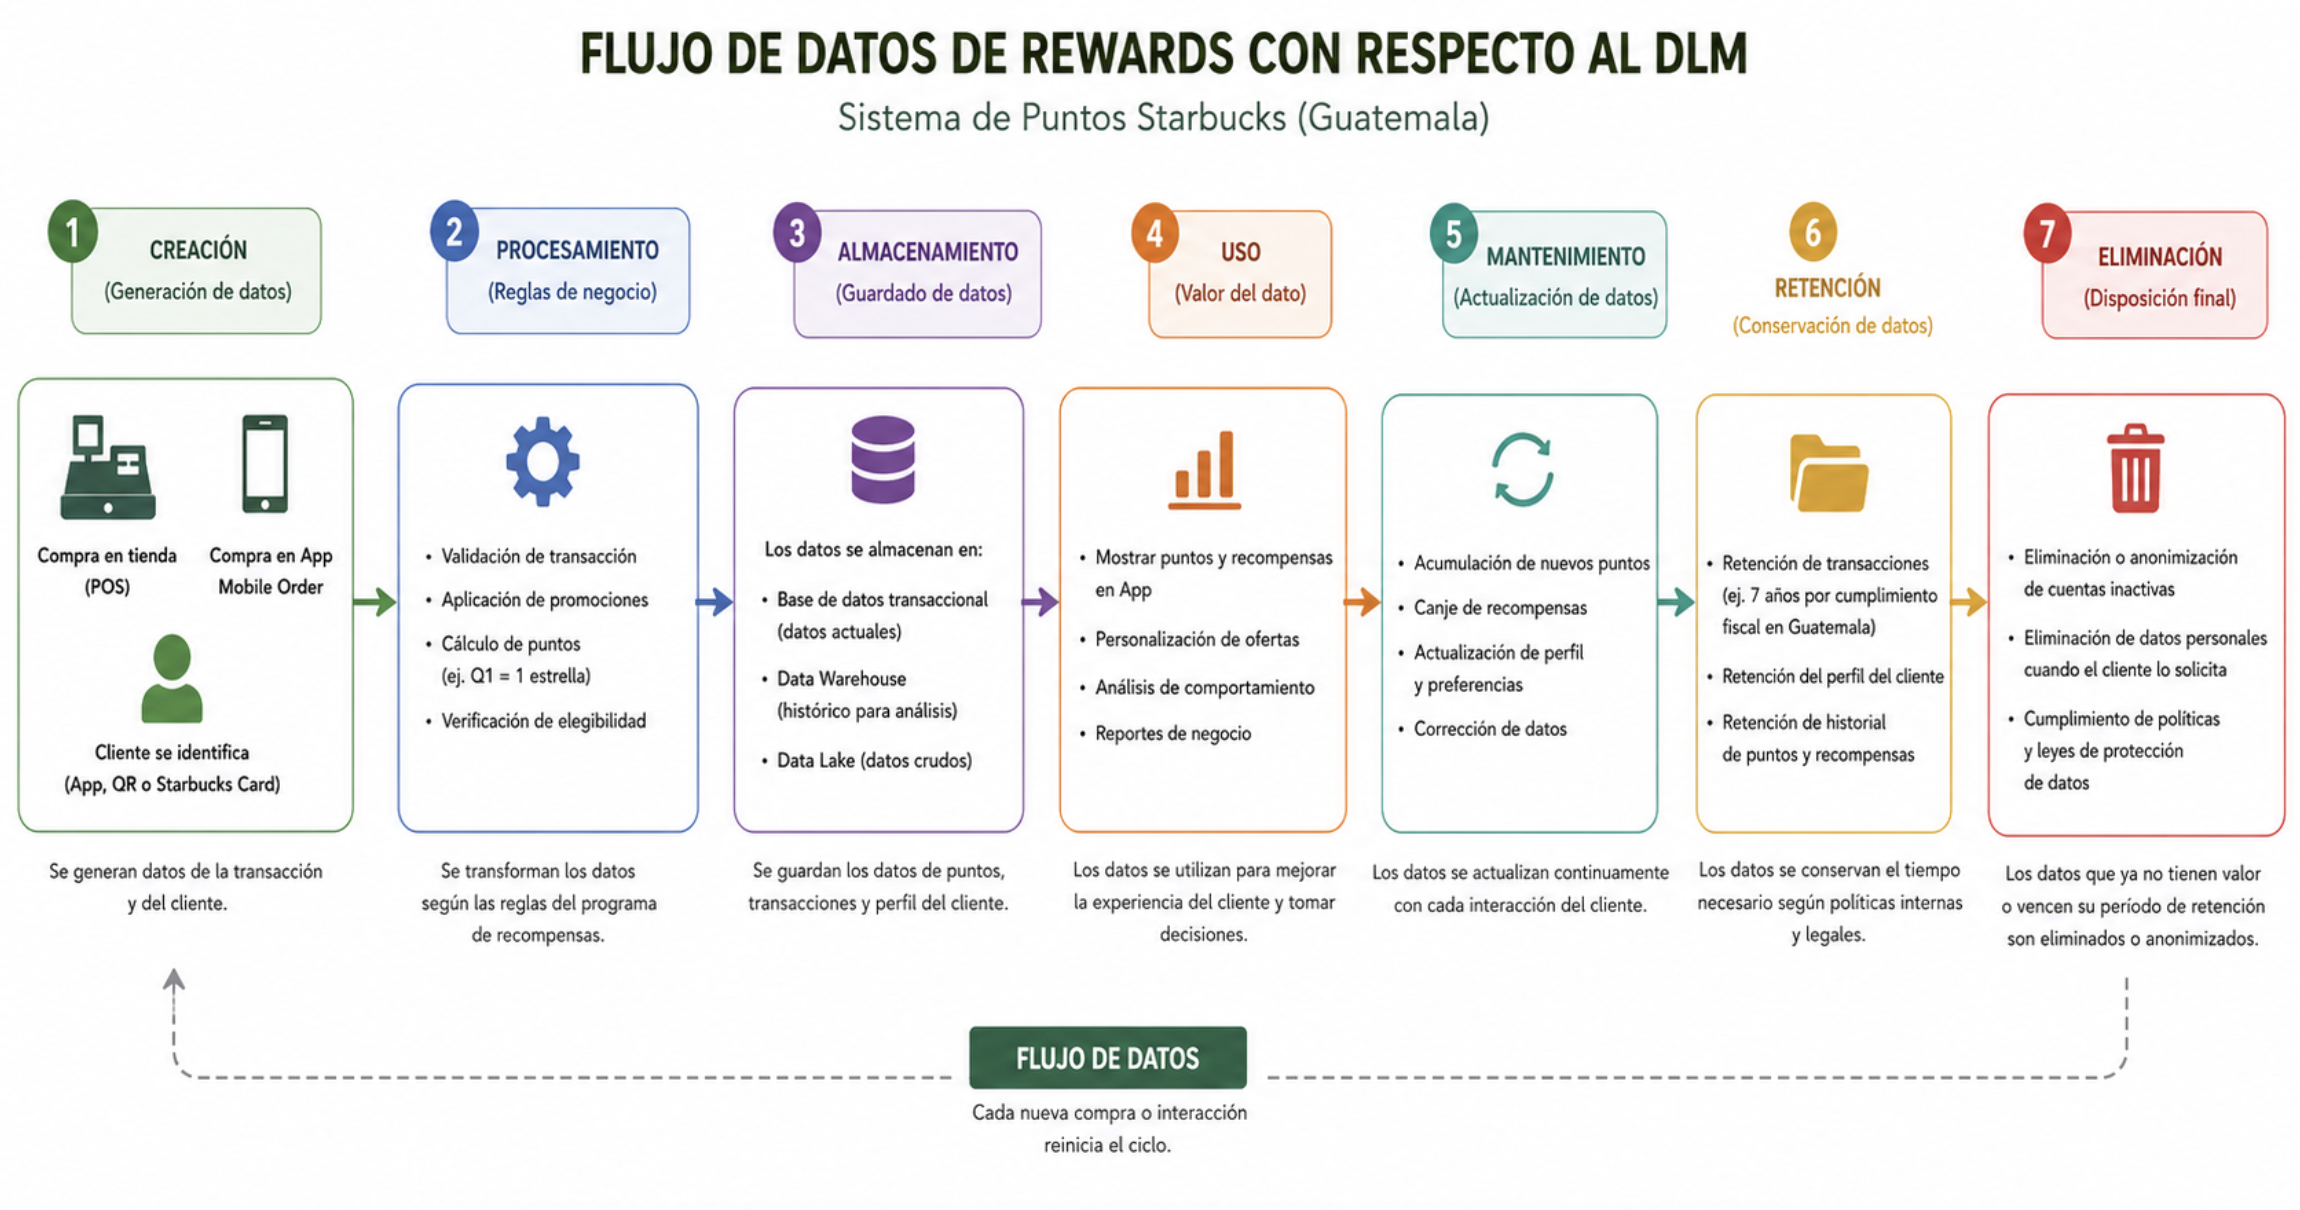



## **Apache Spark**

Apache Spark es una herramienta utilizada en el sistema de rewards de Starbucks para procesar grandes volúmenes de datos de forma rápida y escalable, especialmente después de que se generan las transacciones en el POS. No se utiliza en la captura de la compra, sino en el back-end del pipeline y en el Data Lifecycle Management (DLM), donde permite limpiar, transformar y organizar los datos, prepararlos para su almacenamiento en data warehouses o data lakes. Además, se usa para actualizar información en masa, manejar datos históricos y apoyar procesos de machine learning.


## **Fallas del sistema**

1. Perdida de datos por falta de identificacion: no todos los clientes se identifican (QR), por tanto los datos son incompletos.

2. Reglas rígidas en el procesamiento: Sistema basado en reglas fijas, difícil de cambiar sin afectar todo, no responde en tiempo real al comportamiento, pipeline poco flexible.

3. Desincronizacion entre sistemas (POS y app).

4. Mala integración entre sistemas: duplicidad de datos, retrasos en actualización.

## **Optimizaciones del sistema**

1. **Mejorar la identificación de clientes:** Para reducir la pérdida de datos, el sistema debe facilitar la identificación del cliente en cada compra. Esto se puede lograr vinculando automáticamente métodos de pago (como tarjetas) con cuentas de rewards, o incentivando el uso de la app mediante beneficios inmediatos (ej: puntos extra por escanear). De esta forma se incrementa la captura de datos y se construyen perfiles más completos.

2. **Implementar un sistema híbrido de reglas y machine learning:** El sistema actual basado en reglas rígidas puede optimizarse incorporando modelos de machine learning que permitan ajustar promociones y recompensas en tiempo real. Las reglas básicas pueden mantenerse, pero complementarse con algoritmos que aprendan del comportamiento del cliente, logrando mayor flexibilidad y adaptabilidad.

3. **Aumentar la resiliencia del sistema (modo offline):** Para evitar pérdida de datos o interrupciones, el sistema debe poder operar sin conexión a internet. El POS puede almacenar eventos localmente y sincronizarlos posteriormente cuando se restablezca la conexión, garantizando continuidad operativa y consistencia de datos.

4. **Adoptar una arquitectura basada en eventos (event-driven):** La integración entre sistemas puede mejorar mediante un modelo donde cada acción (como una compra) genere un evento que se distribuya en tiempo real a todos los sistemas conectados. Esto elimina silos de información y asegura que los datos estén sincronizados de forma inmediata.

    Debe ir más allá del historial de compras e incluir variables como ubicación, hora, frecuencia de consumo y comportamiento reciente. Esto permite generar ofertas más relevantes y evitar percepciones negativas, como descuentos mal asignados a clientes frecuentes.

## **Oportunidades de mejora**

1. Pasar de reglas a IA (pipeline inteligente)

2. Explicabilidad del sistema, mostrar: cómo se ganan puntos, progreso claro

3. Mejor manejo del ciclo de vida (DLM): expiración clara, historial transparente, control del usuario

## **Riesgo de seguridad y cómo reforzarlos**

1. **Compromiso de cuentas**

    Riesgo: acceso no autorizado mediante credenciales filtradas o phishing (canje de puntos/saldo).

    Controles: MFA (doble verificación), detección de credential-stuffing, rate limiting, alertas de login y canje.

2. **Suplantación de identidad del cliente**

    Riesgo: uso de QR para acreditar puntos a otra cuenta.

    Controles: QR dinámicos (el código cambia constantemente), validación en backend, límites por sesión y dispositivo.

3. **Integraciones/API inseguras**

    Riesgo: endpoints mal protegidos entre POS, app y backend.

    Controles: autenticación fuerte (OAuth2 –solo sistemas autorizados pueden comunicarse–), mTLS entre servicios (conexión segura entre sistemas, es como una doble capa de seguridad), validación estricta de inputs, y revisiones programadas de APIs.

## **Conclusiones**

- El sistema de rewards de Starbucks depende de un pipeline de datos que inicia en el POS y permite transformar compras en información útil para el negocio.

- La correcta gestión del Data Lifecycle Management (DLM) es clave para asegurar que los datos sean útiles, actualizados y confiables durante todo su ciclo de vida.

- Existen fallas importantes como pérdida de datos, reglas rígidas y falta de integración, que afectan la calidad del sistema y la experiencia del cliente.

- Herramientas como Apache Spark permiten procesar grandes volúmenes de datos, optimizando el análisis, almacenamiento.

- La seguridad es un factor crítico, ya que proteger cuentas, identidad y conexiones garantiza la confianza del usuario y el correcto funcionamiento del sistema.

# **Referencias**

  - Oracle. (s.f.). Oracle MICROS Simphony POS System.
  https://www.oracle.com/food-beverage/pos-systems/simphony/

- Apache Software Foundation. (s.f.). Apache Spark Documentation.
https://spark.apache.org/docs/latest/

- Amazon Web Services (AWS). (s.f.). What is Data Pipeline?
https://aws.amazon.com/what-is/data-pipeline/

- Google Cloud. (s.f.). Data Lifecycle Management.
https://cloud.google.com/architecture/data-lifecycle-management

- Microsoft. (s.f.). What is Machine Learning?
https://learn.microsoft.com/en-us/azure/machine-learning/overview-what-is-ml

- OWASP Foundation. (s.f.). API Security Top 10.
https://owasp.org/www-project-api-security/

- IBM. (s.f.). What is Apache Spark?
https://www.ibm.com/topics/apache-spark

- Korona POS. (s.f.). Starbucks POS System Overview.
https://koronapos.com/blog/starbucks-pos-system/

- OpenAI. (2026). ChatGPT (modelo GPT-5.3) – Apoyo en análisis, explicación y estructuración del sistema de datos, pipeline, DLM y seguridad.

In [ ]:
import requests, json, re
from datetime import date, datetime

# Cargar usuarios desde GitHub
url = "https://raw.githubusercontent.com/danielpinol/Starbucks_demo_Intro_a_Datos/main/starbucks_usuarios%20(1).js"
texto = requests.get(url).text
texto = re.search(r'const usuarios = (\[.*?\]);', texto, re.DOTALL).group(1)
texto = re.sub(r'//.*', '', texto)
texto = re.sub(r'(\w+):', r'"\1":', texto)
texto = re.sub(r"'([^']*)'", r'"\1"', texto)
texto = re.sub(r',\s*([}\]])', r'\1', texto)
usuarios = json.loads(texto)

# Bebidas disponibles
bebidas = [
    "Frappuccino de caramelo", "Latte de vainilla", "Matcha latte",
    "Cappuccino", "Cold brew", "Mocha", "Te chai latte",
    "Americano", "Frappuccino de chocolate", "Espresso doble"
]

# Login
nombre = input("Nombre de usuario: ")
contrasena = input("Contrasena: ")

usuario = next((u for u in usuarios if u["nombre"] == nombre and u["contrasena"] == contrasena), None)

if not usuario:
    print("Usuario o contrasena incorrectos")
else:
    print(f"\nBienvenido, {usuario['nombre']}! Tienes {usuario['estrellas']} estrellas.")

    # Revisar cumpleanos
    hoy = date.today()
    cumple = datetime.strptime(usuario["cumpleanos"], "%Y-%m-%d").date()

    if cumple.day == hoy.day and cumple.month == hoy.month:
        print("\nFeliz cumpleanos! Escoge tu bebida gratis:")
        for i, b in enumerate(bebidas, 1):
            print(f"  {i}. {b}")
        opcion = int(input("\nNumero de bebida: ")) - 1
        print(f"Tu bebida gratis es: {bebidas[opcion]}")

    # Acumular compras
    while True:
        entrada = input("\nMonto de compra en Q (o 'salir'): ")
        if entrada == "salir":
            break

        usuario["estrellas"] += round(float(entrada))
        print(f"Total de estrellas: {usuario['estrellas']}")

        if usuario["estrellas"] >= 1500:
            print("\nLlegaste a 1500 estrellas! Escoge tu bebida gratis:")
            for i, b in enumerate(bebidas, 1):
                print(f"  {i}. {b}")
            opcion = int(input("\nNumero de bebida: ")) - 1
            print(f"Tu bebida gratis es: {bebidas[opcion]}")
            break

    print(f"\nSesion terminada. {usuario['nombre']} tiene {usuario['estrellas']} estrellas.")

Nombre de usuario: Daniel Piñol
Contrasena: pelota

Bienvenido, Daniel Piñol! Tienes 0 estrellas.

Monto de compra en Q (o 'salir'): 200
Total de estrellas: 200

Monto de compra en Q (o 'salir'): 1000
Total de estrellas: 1200

Monto de compra en Q (o 'salir'): 400
Total de estrellas: 1600

Llegaste a 1500 estrellas! Escoge tu bebida gratis:
  1. Frappuccino de caramelo
  2. Latte de vainilla
  3. Matcha latte
  4. Cappuccino
  5. Cold brew
  6. Mocha
  7. Te chai latte
  8. Americano
  9. Frappuccino de chocolate
  10. Espresso doble

Numero de bebida: 6
Tu bebida gratis es: Mocha

Sesion terminada. Daniel Piñol tiene 1600 estrellas.
